100%|██████████| 5/5 [00:00<00:00, 31441.56it/s]


Visualizing sample 0


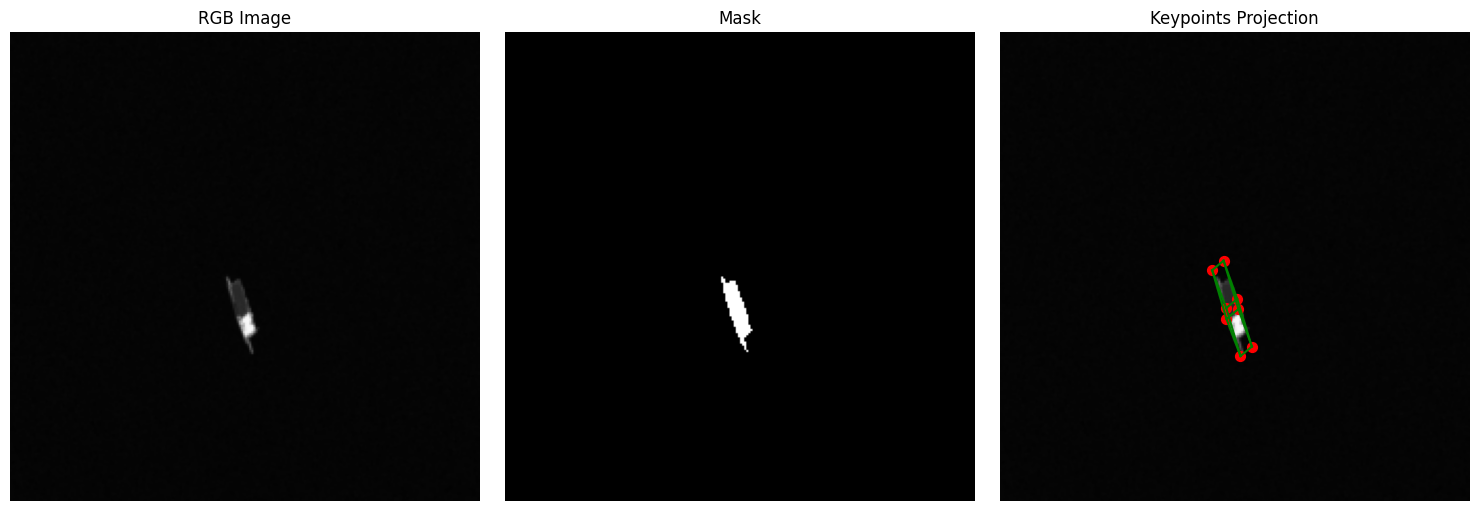

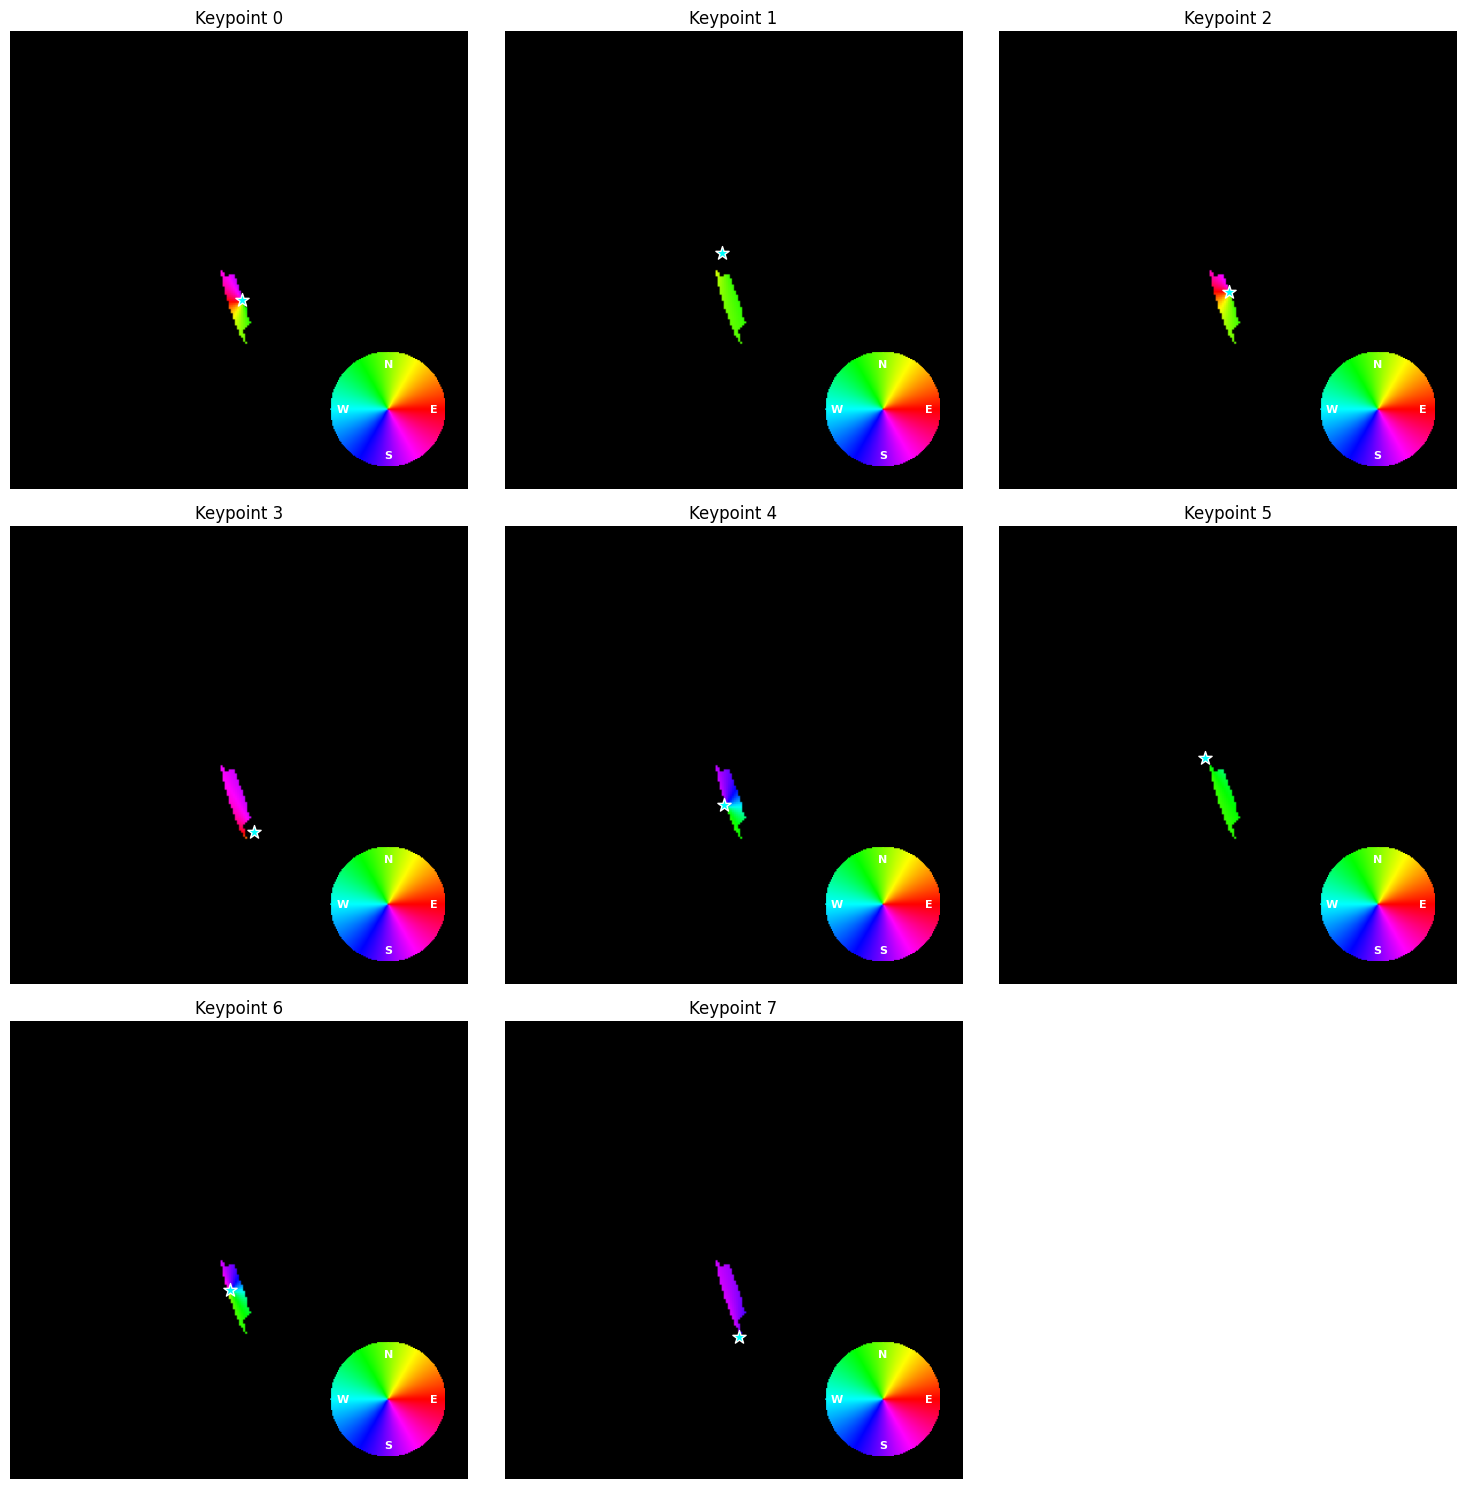

/tmp/ipykernel_35/3684875098.py:1234: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to pretrained.pth/resnet18-5c106cde.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 504MB/s]


Testing on synthetic dataset...
Batch 2400/2400: Orientation Error: 15.93 deg, Translation Error: [0.02, 0.07, 0.03] (mag: 0.08) m            


Testing on real dataset...
Batch 5/5: Orientation Error: 73.72 deg, Translation Error: [-0.08, 0.04, 3.04] (mag: 3.04) m        


Results Summary:
+----------------------+------------------------------+------------------------------+
| Metric               | SPEED synthetic test-set     | SPEED real test-set          |
+----------------------+------------------------------+------------------------------+
| Mean ET (m)          | [0.013 -0.016 7.263]         | [-0.157 0.092 2.605]         |
| Mean ET mag (m)      | 7.2634                       | 2.6110                       |
| Median ET mag (m)    | 1.085                        | 3.037                        |
| Mean ER (deg)        | 65.9998                      | 123.1995                     |
| Median ER (deg)      | 16.1034                      | 148.0221                     |
+----------

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchinfo import summary
from scipy.io import loadmat
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm
import torch.utils.model_zoo as model_zoo
import math
import cv2
from matplotlib.colors import hsv_to_rgb

def visualize_object_with_bbox(rgb_img, mask, hcoords, figsize=(15, 5)):
    """Visualize RGB, mask, and projected keypoints"""
    plt.figure(figsize=figsize)
    
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title('RGB Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(rgb_img)
    plt.title('Keypoints Projection')
    
    points_2d = hcoords[:, :2].numpy()
    
    segments = {
        'top_square': [(0, 1), (1, 2), (2, 3), (3, 0)],  # Top square
        'vertical': [(0, 4), (1, 5), (2, 6), (3, 7)],     # Vertical connections
        'base_square': [(4, 5), (5, 6), (6, 7), (7, 4)],   # Base square
        'antenna': [(1, 8), (2, 9), (3, 10)]              # Antenna connections
    }
    
    segment_colors = {
        'base_square': 'g',   # Blue
        'vertical': 'g',      # Green
        'top_square': 'g',    # Cyan 
        'antenna': 'g'        # Magenta
    }
    
    for seg_type, connections in segments.items():
        color = segment_colors[seg_type]
        for p1_idx, p2_idx in connections:
            if p1_idx < len(points_2d) and p2_idx < len(points_2d):
                plt.plot([points_2d[p1_idx, 0], points_2d[p2_idx, 0]],
                         [points_2d[p1_idx, 1], points_2d[p2_idx, 1]],
                         f'{color}-', linewidth=1.5, label=seg_type if connections.index((p1_idx, p2_idx)) == 0 else "")
    
    plt.scatter(points_2d[:, 0], points_2d[:, 1], c='r', s=50)
    
    
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_vertex(vertex, vertex_weights, keypoints=None):
    """
    Visualize vertex vectors with directional coloring on a black background.
    Also plots the keypoints locations if provided.
    
    Args:
        vertex: Vertex vectors [batch, channels, height, width]
        vertex_weights: Vertex weights [batch, 1, height, width]
        keypoints: Optional keypoints to plot [8, 3] (hcoords)
    """
    
    # Apply weights to vertex
    vertex = vertex * vertex_weights
    
    # Changed to 3x3 grid to accommodate 8 keypoints
    plt.figure(figsize=(15, 15))
    n_keypoints = vertex.shape[1] // 2

    # Create directional images for each keypoint
    for i in range(n_keypoints):
        ax = plt.subplot(3, 3, i+1)
        
        # Get x and y components
        vx = vertex[0, 2*i].cpu().numpy()
        vy = vertex[0, 2*i+1].cpu().numpy()
        
        # Calculate angle and magnitude
        angle = np.arctan2(vy, vx)
        magnitude = np.sqrt(vx**2 + vy**2)
        
        # Create HSV image
        h, w = vx.shape
        hsv_img = np.zeros((h, w, 3))
        
        # Calculate normalized angle (hue), but flip the angle to match the legend
        # This ensures colors in the visualization match the direction legend
        hsv_img[:, :, 0] = ((-angle + 2*np.pi) % (2*np.pi)) / (2*np.pi)  # Hue from angle
        hsv_img[:, :, 1] = 1.0  # Full saturation
        
        # Get mask of valid pixels
        mask = vertex_weights[0, 0].cpu().numpy() > 0
        
        # Set value channel (brightness)
        hsv_img[:, :, 2] = np.zeros_like(magnitude)  # Black background
        if mask.any() and magnitude[mask].max() > 0:
            hsv_img[:, :, 2][mask] = np.clip(magnitude[mask] / magnitude[mask].max(), 0, 1)
        
        # Convert to RGB
        rgb_img = hsv_to_rgb(hsv_img)
        
        plt.imshow(rgb_img)
        
        # Plot keypoint if provided
        if keypoints is not None and i < len(keypoints):
            kp_x, kp_y = int(keypoints[i, 0]), int(keypoints[i, 1])
            if 0 <= kp_x < w and 0 <= kp_y < h:
                plt.scatter(kp_x, kp_y, c='cyan', s=100, marker='*', edgecolors='white')
        
        plt.title(f'Keypoint {i}')
        plt.axis('off')

        # Add inset legend to the bottom right
        ax_inset = ax.inset_axes([0.7, 0.05, 0.25, 0.25])
        
        # Generate a color wheel
        size = 100
        center = size // 2
        y, x = np.ogrid[:size, :size]
        dist = np.sqrt((x - center)**2 + (y - center)**2)
        
        # Create a circular mask
        mask_wheel = dist <= center
        
        # Generate the color wheel
        angles = np.arctan2(center - y, x - center)
        hues = ((angles + 2*np.pi) % (2*np.pi)) / (2*np.pi)
        
        # Create HSV image
        hsv_wheel = np.zeros((size, size, 3))
        hsv_wheel[:, :, 0] = hues
        hsv_wheel[:, :, 1] = 1.0 # Use full saturation for simplicity
        hsv_wheel[:, :, 2] = mask_wheel.astype(float)
        
        # Convert to RGB
        rgb_wheel = hsv_to_rgb(hsv_wheel)
        
        ax_inset.imshow(rgb_wheel)
        ax_inset.axis('off')
        
        # Add direction labels
        directions = ['E', 'N', 'W', 'S']
        angles_text = [0, np.pi/2, np.pi, 3*np.pi/2]
        radius = center * 0.8
        
        for angle_text, direction in zip(angles_text, directions):
            x_t = center + radius * np.cos(angle_text)
            y_t = center - radius * np.sin(angle_text)
            ax_inset.text(x_t, y_t, direction, ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=8)
    
    plt.tight_layout()
    plt.show()

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm

def dcm2quat(dcm):
        """ Computing quaternion from direction cosine matrix, inverse of quat2dcm.
        Arguments:
            dcm: (3,3) numpy.ndarray - direction cosine matrix
        Returns:
            q: (4,) numpy.ndarray - unit quaternion (scalar-first) [w, x, y, z]
        """
        # Handle batch input
        if dcm.ndim == 3:
            return np.array([dcm2quat(dcm_i) for dcm_i in dcm])
        
        # Compute trace of the matrix
        trace = np.trace(dcm)
        
        if trace > 0:
            # Trace is positive
            S = np.sqrt(trace + 1.0) * 2
            q0 = 0.25 * S
            q1 = (dcm[2, 1] - dcm[1, 2]) / S
            q2 = (dcm[0, 2] - dcm[2, 0]) / S
            q3 = (dcm[1, 0] - dcm[0, 1]) / S
        elif dcm[0, 0] > dcm[1, 1] and dcm[0, 0] > dcm[2, 2]:
            S = np.sqrt(1.0 + dcm[0, 0] - dcm[1, 1] - dcm[2, 2]) * 2
            q0 = (dcm[2, 1] - dcm[1, 2]) / S
            q1 = 0.25 * S
            q2 = (dcm[0, 1] + dcm[1, 0]) / S
            q3 = (dcm[0, 2] + dcm[2, 0]) / S
        elif dcm[1, 1] > dcm[2, 2]:
            S = np.sqrt(1.0 + dcm[1, 1] - dcm[0, 0] - dcm[2, 2]) * 2
            q0 = (dcm[0, 2] - dcm[2, 0]) / S
            q1 = (dcm[0, 1] + dcm[1, 0]) / S
            q2 = 0.25 * S
            q3 = (dcm[1, 2] + dcm[2, 1]) / S
        else:
            S = np.sqrt(1.0 + dcm[2, 2] - dcm[0, 0] - dcm[1, 1]) * 2
            q0 = (dcm[1, 0] - dcm[0, 1]) / S
            q1 = (dcm[0, 2] + dcm[2, 0]) / S
            q2 = (dcm[1, 2] + dcm[2, 1]) / S
            q3 = 0.25 * S
        
        # Form quaternion and normalize
        q = np.array([q0, q1, q2, q3])
        q = q / np.linalg.norm(q)
        
        return q

def get_3d_bbox(keypts_3d):
    """
    Compute a 3D bounding box (cuboid) that encloses the given keypoints.
    
    Args:
        keypts_3d: numpy array of shape (N, 3) where N is the number of keypoints
    
    Returns:
        bbox: numpy array of shape (8, 3) representing the corners of the 3D bounding box
    """
    # Find min and max values for each dimension
    min_vals = np.min(keypts_3d, axis=0)
    max_vals = np.max(keypts_3d, axis=0)
    
    # Create the 8 corners of the bounding box
    bbox = np.array([
        [min_vals[0], min_vals[1], min_vals[2]],  # 0: min_x, min_y, min_z
        [max_vals[0], min_vals[1], min_vals[2]],  # 1: max_x, min_y, min_z
        [max_vals[0], max_vals[1], min_vals[2]],  # 2: max_x, max_y, min_z
        [min_vals[0], max_vals[1], min_vals[2]],  # 3: min_x, max_y, min_z
        [min_vals[0], min_vals[1], max_vals[2]],  # 4: min_x, min_y, max_z
        [max_vals[0], min_vals[1], max_vals[2]],  # 5: max_x, min_y, max_z
        [max_vals[0], max_vals[1], max_vals[2]],  # 6: max_x, max_y, max_z
        [min_vals[0], max_vals[1], max_vals[2]]   # 7: min_x, max_y, max_z
    ])
    
    return bbox
    
def get_data_pts_2d(pts_3d, RT, cam_K):
    pts_2d=np.matmul(pts_3d,RT[:,:3].T)+RT[:,3:].T
    pts_2d=np.matmul(pts_2d,cam_K.T)
    pts_2d=pts_2d[:,:2]/pts_2d[:,2:]
    return pts_2d

def compute_vertex_hcoords(mask, hcoords, use_motion=False):
    h,w=mask.shape
    m=hcoords.shape[0]
    xy = np.argwhere(mask == 1)[:, [1, 0]]
    vertex = xy[:, None, :]*hcoords[None, :, 2:]
    vertex = hcoords[None, :, :2] - vertex
    if not use_motion:
        norm = np.linalg.norm(vertex, axis=2, keepdims=True)
        norm[norm<1e-3] += 1e-3
        vertex = vertex / norm

    vertex_out=np.zeros([h,w,m,2],np.float32)
    vertex_out[xy[:, 1], xy[:, 0]] = vertex
    return  np.reshape(vertex_out,[h,w,m*2])

def smooth_l1_loss(vertex_pred, vertex_targets, vertex_weights, sigma=1.0, normalize=True, reduce=True):
    '''
    :param vertex_pred:     [b,vn*2,h,w]
    :param vertex_targets:  [b,vn*2,h,w]
    :param vertex_weights:  [b,1,h,w]
    :param sigma:
    :param normalize:
    :param reduce:
    :return:
    '''
    b,ver_dim,_,_=vertex_pred.shape
    sigma_2 = sigma ** 2
    vertex_diff = vertex_pred - vertex_targets
    diff = vertex_weights * vertex_diff
    abs_diff = torch.abs(diff)
    smoothL1_sign = (abs_diff < 1. / sigma_2).detach().float()
    in_loss = torch.pow(diff, 2) * (sigma_2 / 2.) * smoothL1_sign \
              + (abs_diff - (0.5 / sigma_2)) * (1. - smoothL1_sign)

    if normalize:
        in_loss=torch.sum(in_loss.view(b,-1),1) / (ver_dim * torch.sum(vertex_weights.view(b,-1),1) + 1e-3)

    if reduce:
       torch.mean(in_loss)

    return in_loss

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

class AverageMeter(object):
    """ Computes and stores the average and current value.
    Can handle both scalar values and numpy arrays.
    """
    def __init__(self, unit='-', is_vector=False):
        self.reset()
        self.unit = unit
        self.is_vector = is_vector

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0
        
    def update(self, val, n=1):
        self.val = val
        
        # Handle initialization for vectors
        if self.count == 0 and isinstance(val, np.ndarray):
            self.sum = np.zeros_like(val, dtype=np.float64)
            
        # Update sum and compute average
        if isinstance(val, np.ndarray):
            self.sum = self.sum + val * n
        else:
            self.sum += val * n
            
        self.count += n
        
        if self.count > 0:
            if isinstance(self.sum, np.ndarray):
                self.avg = self.sum / self.count
            else:
                self.avg = self.sum / self.count
                
    def magnitude(self):
        """Return magnitude for vector quantities"""
        if isinstance(self.avg, np.ndarray):
            return np.linalg.norm(self.avg)
        return self.avg

def b_inv(b_mat):
    '''
    code from
    https://stackoverflow.com/questions/46595157/how-to-apply-the-torch-inverse-function-of-pytorch-to-every-sample-in-the-batc
    :param b_mat:
    :return:
    '''
    eye = b_mat.new_ones(b_mat.size(-1)).diag().expand_as(b_mat)
    b_mat_reg = b_mat.clone()
    b_mat_reg = b_mat_reg + torch.eye(b_mat.size(-1), device=b_mat.device) * 1e-6
    b_inv = torch.linalg.solve(b_mat_reg, eye)
    return b_inv

def generate_hypothesis(direct, coords, idxs):
    """
    PyTorch implementation of generate_hypothesis CUDA kernel
    
    Args:
        direct: Directional vectors [tn, vn, 2]
        coords: Coordinates [tn, 2]
        idxs: Sample indices [hn, vn, 2]
    
    Returns:
        Hypothesis points [hn, vn, 2]
    """
    hn, vn = idxs.shape[0], idxs.shape[1]
    hypo_pts = torch.zeros((hn, vn, 2), device=direct.device, dtype=direct.dtype)
    
    # Get indices for first and second points
    t0 = idxs[:, :, 0].long()  # [hn, vn]
    t1 = idxs[:, :, 1].long()  # [hn, vn]
    
    # Get batch indices for each point
    idx_hn = torch.arange(hn, device=direct.device).view(-1, 1).expand(-1, vn)
    idx_vn = torch.arange(vn, device=direct.device).view(1, -1).expand(hn, -1)
    
    # Get normal vectors (perpendicular to direction)
    nx0 = direct[t0, idx_vn, 1]  # [hn, vn]
    ny0 = -direct[t0, idx_vn, 0]  # [hn, vn]
    nx1 = direct[t1, idx_vn, 1]  # [hn, vn]
    ny1 = -direct[t1, idx_vn, 0]  # [hn, vn]
    
    # Get coordinates
    cx0 = coords[t0, 0]  # [hn, vn]
    cy0 = coords[t0, 1]  # [hn, vn]
    cx1 = coords[t1, 0]  # [hn, vn]
    cy1 = coords[t1, 1]  # [hn, vn]
    
    # Compute determinants for intersection calculation
    det = nx1 * ny0 - nx0 * ny1
    det2 = ny1 * nx0 - ny0 * nx1
    
    # Avoid division by zero
    mask = (torch.abs(det) > 1e-6) & (torch.abs(det2) > 1e-6)
    
    # Calculate intersection points
    y = (nx1 * (nx0 * cx0 + ny0 * cy0) - nx0 * (nx1 * cx1 + ny1 * cy1)) / (det + 1e-8)
    x = (ny1 * (nx0 * cx0 + ny0 * cy0) - ny0 * (nx1 * cx1 + ny1 * cy1)) / (det2 + 1e-8)
    
    # Apply mask to avoid incorrect intersections
    x = torch.where(mask, x, torch.zeros_like(x))
    y = torch.where(mask, y, torch.zeros_like(y))
    
    hypo_pts[:, :, 0] = x
    hypo_pts[:, :, 1] = y
    
    return hypo_pts

def voting_for_hypothesis(direct, coords, hypo_pts, inliers, inlier_thresh):
    """
    PyTorch implementation of voting_for_hypothesis CUDA kernel
    
    Args:
        direct: Directional vectors [tn, vn, 2]
        coords: Coordinates [tn, 2]
        hypo_pts: Hypothesis points [hn, vn, 2]
        inliers: Output tensor for inliers [hn, vn, tn]
        inlier_thresh: Threshold for inlier determination
    """
    hn, vn = hypo_pts.shape[0], hypo_pts.shape[1]
    tn = coords.shape[0]
    
    # Expand dimensions for broadcasting
    coords_expanded = coords.unsqueeze(0).unsqueeze(0)  # [1, 1, tn, 2]
    hypo_pts_expanded = hypo_pts.unsqueeze(2)  # [hn, vn, 1, 2]
    direct_expanded = direct.unsqueeze(0)  # [1, tn, vn, 2]
    
    # Calculate direction vector from coordinate to hypothesis point
    dx = hypo_pts_expanded[:, :, :, 0] - coords_expanded[:, :, :, 0]  # [hn, vn, tn]
    dy = hypo_pts_expanded[:, :, :, 1] - coords_expanded[:, :, :, 1]  # [hn, vn, tn]
    
    # Get directional vectors for all points
    nx = direct_expanded[:, :, :, 0]  # [1, tn, vn]
    ny = direct_expanded[:, :, :, 1]  # [1, tn, vn]
    
    # Transpose to match dimensions
    nx = nx.permute(0, 2, 1)  # [1, vn, tn]
    ny = ny.permute(0, 2, 1)  # [1, vn, tn]
    
    # Expand dimensions to match
    nx = nx.expand(hn, -1, -1)  # [hn, vn, tn]
    ny = ny.expand(hn, -1, -1)  # [hn, vn, tn]
    
    # Calculate norms
    norm1 = torch.sqrt(nx * nx + ny * ny)  # [hn, vn, tn]
    norm2 = torch.sqrt(dx * dx + dy * dy)  # [hn, vn, tn]
    
    # Calculate angle distance (dot product / product of norms)
    valid_mask = (norm1 > 1e-6) & (norm2 > 1e-6)
    angle_dist = torch.zeros_like(norm1)
    angle_dist[valid_mask] = (dx[valid_mask] * nx[valid_mask] + dy[valid_mask] * ny[valid_mask]) / (norm1[valid_mask] * norm2[valid_mask])
    
    # Mark inliers
    inliers.zero_()
    inliers[angle_dist > inlier_thresh] = 1

def ransac_voting_layer_v3(mask, vertex, round_hyp_num=512, inlier_thresh=0.99, confidence=0.99, max_iter=20,
                           min_num=5, max_num=30000):
    '''
    :param mask:      [b,h,w]
    :param vertex:    [b,h,w,vn,2]
    :param round_hyp_num:
    :param inlier_thresh:
    :return: [b,vn,2]
    '''
    b, h, w, vn, _ = vertex.shape
    batch_win_pts = []
    for bi in range(b):
        hyp_num = 0
        cur_mask = (mask[bi]).byte()
        foreground_num = torch.sum(cur_mask)

        # if too few points, just skip it
        if foreground_num < min_num:
            win_pts = torch.zeros([1, vn, 2], dtype=torch.float32, device=mask.device)
            batch_win_pts.append(win_pts)  # [1,vn,2]
            continue

        # if too many inliers, we randomly down sample it
        if foreground_num > max_num:
            selection = torch.zeros(cur_mask.shape, dtype=torch.float32, device=mask.device).uniform_(0, 1)
            selected_mask = (selection < (max_num / foreground_num.float()))
            cur_mask *= selected_mask

        coords = torch.nonzero(cur_mask).float()  # [tn,2]
        coords = coords[:, [1, 0]]
        direct = vertex[bi].masked_select(torch.unsqueeze(torch.unsqueeze(cur_mask.bool(), 2), 3))  # [tn,vn,2]
        direct = direct.view([coords.shape[0], vn, 2])
        tn = coords.shape[0]
        idxs = torch.zeros([round_hyp_num, vn, 2], dtype=torch.int32, device=mask.device).random_(0, direct.shape[0])
        all_win_ratio = torch.zeros([vn], dtype=torch.float32, device=mask.device)
        all_win_pts = torch.zeros([vn, 2], dtype=torch.float32, device=mask.device)

        cur_iter = 0
        while True:
            # generate hypothesis
            cur_hyp_pts = generate_hypothesis(direct, coords, idxs)  # [hn,vn,2]

            # voting for hypothesis
            cur_inlier = torch.zeros([round_hyp_num, vn, tn], dtype=torch.uint8, device=mask.device)
            voting_for_hypothesis(direct, coords, cur_hyp_pts, cur_inlier, inlier_thresh)  # [hn,vn,tn]

            # find max
            cur_inlier_counts = torch.sum(cur_inlier, 2)                   # [hn,vn]
            cur_win_counts, cur_win_idx = torch.max(cur_inlier_counts, 0)  # [vn]
            cur_win_pts = cur_hyp_pts[cur_win_idx, torch.arange(vn)]
            cur_win_ratio = cur_win_counts.float() / tn

            # update best point
            larger_mask = all_win_ratio < cur_win_ratio
            all_win_pts[larger_mask, :] = cur_win_pts[larger_mask, :]
            all_win_ratio[larger_mask] = cur_win_ratio[larger_mask]

            # check confidence
            hyp_num += round_hyp_num
            cur_iter += 1
            cur_min_ratio = torch.min(all_win_ratio)
            if (1 - (1 - cur_min_ratio ** 2) ** hyp_num) > confidence or cur_iter > max_iter:
                break

        # compute mean intersection again
        normal = torch.zeros_like(direct)   # [tn,vn,2]
        normal[:, :, 0] = direct[:, :, 1]
        normal[:, :, 1] = -direct[:, :, 0]
        all_inlier = torch.zeros([1, vn, tn], dtype=torch.uint8, device=mask.device)
        all_win_pts = torch.unsqueeze(all_win_pts, 0)  # [1,vn,2]
        voting_for_hypothesis(direct, coords, all_win_pts, all_inlier, inlier_thresh)  # [1,vn,tn]

        # coords [tn,2] normal [vn,tn,2]
        all_inlier=torch.squeeze(all_inlier.float(),0)              # [vn,tn]
        normal=normal.permute(1,0,2)                                # [vn,tn,2]
        normal=normal*torch.unsqueeze(all_inlier,2)                 # [vn,tn,2] outlier is all zero

        b=torch.sum(normal*torch.unsqueeze(coords,0),2)             # [vn,tn]
        ATA=torch.matmul(normal.permute(0,2,1),normal)              # [vn,2,2]
        ATb=torch.sum(normal*torch.unsqueeze(b,2),1)                # [vn,2]
        all_win_pts=torch.matmul(b_inv(ATA),torch.unsqueeze(ATb,2)) # [vn,2,1]
        batch_win_pts.append(all_win_pts[None,:,:,0])

    batch_win_pts=torch.cat(batch_win_pts)
    return batch_win_pts

def pnp(points_3d, points_2d, camera_matrix, dist_coeffs, method=cv2.SOLVEPNP_ITERATIVE):

    assert points_3d.shape[0] == points_2d.shape[0], 'points 3D and points 2D must have same number of vertices'
    if method==cv2.SOLVEPNP_EPNP:
        points_3d=np.expand_dims(points_3d, 0)
        points_2d=np.expand_dims(points_2d, 0)

    points_2d = np.ascontiguousarray(points_2d.astype(np.float64))
    points_3d = np.ascontiguousarray(points_3d.astype(np.float64))
    camera_matrix = camera_matrix.astype(np.float64)
    _, R_exp, t = cv2.solvePnP(points_3d,
                               points_2d,
                               camera_matrix,
                               dist_coeffs,
                               flags=method)
    R, _ = cv2.Rodrigues(R_exp)
    
    return np.concatenate([R, t], axis=-1)

def error_translation(t_pr, t_gt):
    t_pr = np.reshape(t_pr, (3,))
    t_gt = np.reshape(t_gt, (3,))

    return t_gt - t_pr

def error_orientation(q_pr, q_gt):
    # q must be [qvec, qcos]
    q_pr = np.reshape(q_pr, (4,))
    q_gt = np.reshape(q_gt, (4,))

    qdot = np.abs(np.dot(q_pr, q_gt))
    qdot = np.minimum(qdot, 1.0)
    return np.rad2deg(2*np.arccos(qdot)) # [deg]

def conv3x3(in_planes, out_planes, stride=1, dilation=1):
    "3x3 convolution with padding"
    
    kernel_size = np.asarray((3, 3))
    
    # Compute the size of the upsampled filter with
    # a specified dilation rate.
    upsampled_kernel_size = (kernel_size - 1) * (dilation - 1) + kernel_size
    
    # Determine the padding that is necessary for full padding,
    # meaning the output spatial size is equal to input spatial size
    full_padding = (upsampled_kernel_size - 1) // 2
    
    # Conv2d doesn't accept numpy arrays as arguments
    full_padding, kernel_size = tuple(full_padding), tuple(kernel_size)
    
    return nn.Conv2d(in_planes, out_planes, kernel_size=kernel_size, stride=stride,
                     padding=full_padding, dilation=dilation, bias=False)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, dilation=1):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride, dilation=dilation)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes, dilation=dilation)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, dilation=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        
        self.conv2 = conv3x3(planes, planes, stride=stride, dilation=dilation)
        
        #self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
        #                       padding=1, bias=False)
        
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

class ResNet(nn.Module):

    def __init__(self,
                 block,
                 layers,
                 num_classes=1000,
                 fully_conv=False,
                 remove_avg_pool_layer=False,
                 output_stride=32):
        
        # Add additional variables to track
        # output stride. Necessary to achieve
        # specified output stride.
        self.output_stride = output_stride
        self.current_stride = 4
        self.current_dilation = 1
        
        self.remove_avg_pool_layer = remove_avg_pool_layer
        
        self.inplanes = 64
        self.fully_conv = fully_conv
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        self.avgpool = nn.AvgPool2d(7)

        self.fc = nn.Linear(512 * block.expansion, num_classes)
        
        if self.fully_conv:
            self.avgpool = nn.AvgPool2d(7, padding=3, stride=1)
            # In the latest unstable torch 4.0 the tensor.copy_
            # method was changed and doesn't work as it used to be
            #self.fc = nn.Conv2d(512 * block.expansion, num_classes, 1)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1, dilation=1):
        downsample = None
         
        if stride != 1 or self.inplanes != planes * block.expansion:
            
            # Check if we already achieved desired output stride.
            if self.current_stride == self.output_stride:
                
                # If so, replace subsampling with a dilation to preserve
                # current spatial resolution.
                self.current_dilation = self.current_dilation * stride
                stride = 1
            else:
                
                # If not, perform subsampling and update current
                # new output stride.
                self.current_stride = self.current_stride * stride
                
            # We don't dilate 1x1 convolution.
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, dilation=self.current_dilation))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes, dilation=self.current_dilation))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x2s = self.relu(x)
        x = self.maxpool(x2s)

        x4s = self.layer1(x)
        x8s = self.layer2(x4s)
        x16s = self.layer3(x8s)
        x32s = self.layer4(x16s)
        x=x32s
        
        if not self.remove_avg_pool_layer:
            x = self.avgpool(x)
        
        if not self.fully_conv:
            x = x.view(x.size(0), -1)
            
        xfc = self.fc(x)

        return x2s,x4s,x8s,x16s,x32s,xfc

def resnet18(pretrained=False, **kwargs):
    """Constructs a ResNet-18 model.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    model = ResNet(BasicBlock, [2, 2, 2, 2], **kwargs)
    if pretrained:
        model.load_state_dict(model_zoo.load_url("https://download.pytorch.org/models/resnet18-5c106cde.pth",model_dir="pretrained.pth"))
    return model

class SPEEDDataset(Dataset):
    def __init__(self, images_dir, json_dir, mask_dir, transform=None):
        self.transform = transform

        self.rgbPthList = []
        self.maskPthList = []
        self.frameInfoList = []
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.mask_dir = mask_dir

        self.cameraMatrix, self.distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')

        keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        self.pts_3dbbox = get_3d_bbox(keypts3d)

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }

            cnt = 0
            for filename in tqdm.tqdm(sorted(os.listdir(self.images_dir))):
                if filename not in lookup:
                    continue
                
                frame_idx = int(''.join(filter(str.isdigit, filename.split('.')[0])))

                pngFilename = filename.replace('.jpg', '.png')
                
                self.rgbPthList.append(os.path.join(self.images_dir, filename))
                self.maskPthList.append(os.path.join(self.mask_dir, pngFilename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                frame_info = {
                    'frame_idx': frame_idx,
                    'q_vbs2tango': q_vbs2tango,
                    'r_Vo2To_vbs': r_Vo2To_vbs
                }
                self.frameInfoList.append(frame_info)

                cnt = cnt + 1
                # if cnt>0:
                #     break

    def __len__(self):
        return len(self.rgbPthList)

    def __getitem__(self, idx):
        rgb_path = self.rgbPthList[idx]
        rgb_img = Image.open(rgb_path).convert('RGB')
        rgb_img = np.array(rgb_img)
        rgb = torch.from_numpy(rgb_img).float().permute(2, 0, 1)
        
        mask_path = self.maskPthList[idx]
        mask_img = Image.open(mask_path).convert('1')
        mask_seg = np.array(mask_img).astype(np.int32)
        mask = torch.from_numpy(mask_seg).long()
        
        frame_info = self.frameInfoList[idx]
        keypts2d = project_keypoints(frame_info['q_vbs2tango'], frame_info['r_Vo2To_vbs'], self.cameraMatrix, self.distCoeffs, self.pts_3dbbox).T # (8, 2)
        hcoords = np.concatenate([keypts2d, np.ones([8, 1], np.float32)], 1)

        q_gt = frame_info['q_vbs2tango']
        r_gt = frame_info['r_Vo2To_vbs']
        
        orig_h, orig_w = mask_seg.shape
        
        rotation_matrix = quat2dcm(frame_info['q_vbs2tango'])
        translation_vector = frame_info['r_Vo2To_vbs'].reshape(3, 1)
        RT = np.hstack((rotation_matrix, translation_vector))
        
        if self.transform:
            rgb = self.transform(rgb)
            mask = self.transform(mask.unsqueeze(0)).squeeze(0)
            
            new_h, new_w = mask.shape
            
            scale_x = new_w / orig_w
            scale_y = new_h / orig_h

            scaled_keypts2d = keypts2d.copy()
            scaled_keypts2d[:, 0] *= scale_x
            scaled_keypts2d[:, 1] *= scale_y
            
            scaled_hcoords = hcoords.copy()
            scaled_hcoords[:, 0] *= scale_x
            scaled_hcoords[:, 1] *= scale_y
            
            mask_np = mask.numpy().astype(np.int32)
            ver_np = compute_vertex_hcoords(mask_np, scaled_hcoords, use_motion=False)
            hcoords = torch.tensor(scaled_hcoords.astype(np.float32))
        else:
            ver_np = compute_vertex_hcoords(mask_seg, hcoords, use_motion=False)
            hcoords = torch.tensor(hcoords.astype(np.float32))
            
        ver = torch.tensor(ver_np, dtype=torch.float32).permute(2, 0, 1)
        ver_weight = mask.unsqueeze(0).float()
        pose = torch.tensor(RT.astype(np.float32))

        return rgb, mask, ver, ver_weight, pose, hcoords, q_gt, r_gt
    
transform = transforms.Compose([
        transforms.Resize((224, 224)),
    ])

syntheticdataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/val.json', mask_dir= '/kaggle/input/speedsplitmaskssamvit-h/speedsplit/speed/masks/trainval' ,transform=transform)
realdataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/real', json_dir='/kaggle/input/speedsplit/speed/real.json', mask_dir= '/kaggle/input/speedsplitmaskssamvit-h/speedsplit/speed/masks/real' ,transform=transform)

num_images = min(1,len(syntheticdataset))
for idx in range(num_images):
    print(f"Visualizing sample {idx}")
    rgb_sample, mask_sample, ver_sample, ver_weight_sample, pose_sample, hcoords_sample, _, _ = syntheticdataset[idx]
    rgb_np = rgb_sample.permute(1, 2, 0).numpy().astype(np.uint8)
    mask_np = mask_sample.numpy()
    
    visualize_object_with_bbox(rgb_np, mask_np, hcoords_sample)

rgb_sample, mask_sample, ver_sample, ver_weight_sample, pose_sample, hcoords_sample, _, _ = syntheticdataset[0]

ver_sample = ver_sample.unsqueeze(0) 
ver_weight_sample = ver_weight_sample.unsqueeze(0)  

visualize_vertex(ver_sample, ver_weight_sample, hcoords_sample)

class Resnet18_8s(nn.Module):
    def __init__(self, ver_dim, seg_dim, fcdim=256, s8dim=128, s4dim=64, s2dim=32, raw_dim=32):
        super(Resnet18_8s, self).__init__()

        # Load the pretrained weights, remove avg pool
        # layer and get the output stride of 8
        resnet18_8s = resnet18(fully_conv=True,
                               pretrained=True,
                               output_stride=8,
                               remove_avg_pool_layer=True)

        self.ver_dim=ver_dim
        self.seg_dim=seg_dim

        # Randomly initialize the 1x1 Conv scoring layer
        resnet18_8s.fc = nn.Sequential(
            nn.Conv2d(resnet18_8s.inplanes, fcdim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(fcdim),
            nn.ReLU(True)
        )
        self.resnet18_8s = resnet18_8s

        # x8s->128
        self.conv8s=nn.Sequential(
            nn.Conv2d(128+fcdim, s8dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s8dim),
            nn.LeakyReLU(0.1,True)
        )
        self.up8sto4s=nn.UpsamplingBilinear2d(scale_factor=2)

        # x4s->64
        self.conv4s=nn.Sequential(
            nn.Conv2d(64+s8dim, s4dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s4dim),
            nn.LeakyReLU(0.1,True)
        )
        self.up4sto2s=nn.UpsamplingBilinear2d(scale_factor=2)

        # x2s->64
        self.conv2s=nn.Sequential(
            nn.Conv2d(64+s4dim, s2dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s2dim),
            nn.LeakyReLU(0.1,True)
        )
        self.up2storaw = nn.UpsamplingBilinear2d(scale_factor=2)

        self.convraw = nn.Sequential(
            nn.Conv2d(3+s2dim, raw_dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(raw_dim),
            nn.LeakyReLU(0.1,True),
            nn.Conv2d(raw_dim, seg_dim+ver_dim, 1, 1)
        )

    def _normal_initialization(self, layer):
        layer.weight.data.normal_(0, 0.01)
        layer.bias.data.zero_()

    def forward(self, x, feature_alignment=False):
        x2s, x4s, x8s, x16s, x32s, xfc = self.resnet18_8s(x)

        fm=self.conv8s(torch.cat([xfc,x8s],1))
        fm=self.up8sto4s(fm)

        fm=self.conv4s(torch.cat([fm,x4s],1))
        fm=self.up4sto2s(fm)

        fm=self.conv2s(torch.cat([fm,x2s],1))
        fm=self.up2storaw(fm)

        x=self.convraw(torch.cat([fm,x],1))
        seg_pred=x[:,:self.seg_dim,:,:]
        ver_pred=x[:,self.seg_dim:,:,:]

        return seg_pred, ver_pred

def visualize_ransac_validation(model, dataset, device, num_samples=3):
    """
    Visualize the RANSAC prediction vs ground truth keypoints to validate the algorithm
    
    Args:
        model: Trained PVNet model
        dataset: Dataset to sample from
        device: Device to run inference on
        num_samples: Number of samples to visualize
    """
    model.eval()
    
    for i in range(min(num_samples, len(dataset))):
        # Get a sample
        rgb, mask, ver, ver_weight, pose, hcoords, q_gt, r_gt = dataset[i]
        
        # Prepare for inference
        rgb_tensor = rgb.unsqueeze(0).to(device)
        
        # Run inference
        with torch.no_grad():
            seg_pred, ver_pred = model(rgb_tensor)
            
        # Get predicted mask
        pred_mask = torch.argmax(seg_pred, 1).cpu().numpy()[0]
        
        # Process vertex predictions
        ver_pred = ver_pred.permute(0, 2, 3, 1)
        b, h, w, vn_2 = ver_pred.shape
        ver_pred = ver_pred.view(b, h, w, vn_2 // 2, 2)
        
        # Apply RANSAC to get the predicted corners
        corner_pred = ransac_voting_layer_v3(torch.argmax(seg_pred, 1), ver_pred)
        corner_pred_np = corner_pred[0].cpu().numpy()
        
        # Convert RGB tensor back to numpy for visualization
        rgb_np = rgb.permute(1, 2, 0).numpy().astype(np.uint8)
        
        # Ground truth keypoints
        gt_keypoints = hcoords.numpy()[:, :2]  # Remove homogeneous coordinate
        
        # Create figure for visualization
        plt.figure(figsize=(15, 10))
        
        # Display original image
        plt.imshow(rgb_np)
        plt.title(f'RANSAC Validation - Sample {i+1}')
        
        # Draw ground truth keypoints and connections (in green)
        segments = {
            'top_square': [(0, 1), (1, 2), (2, 3), (3, 0)],
            'vertical': [(0, 4), (1, 5), (2, 6), (3, 7)],
            'base_square': [(4, 5), (5, 6), (6, 7), (7, 4)]
        }
        
        # Draw ground truth in green
        for seg_type, connections in segments.items():
            for p1_idx, p2_idx in connections:
                if p1_idx < len(gt_keypoints) and p2_idx < len(gt_keypoints):
                    plt.plot([gt_keypoints[p1_idx, 0], gt_keypoints[p2_idx, 0]],
                             [gt_keypoints[p1_idx, 1], gt_keypoints[p2_idx, 1]],
                             'g-', linewidth=1.5)
        
        plt.scatter(gt_keypoints[:, 0], gt_keypoints[:, 1], c='g', s=50, marker='o', label='Ground Truth')
        
        # Draw predicted keypoints and connections (in red)
        for seg_type, connections in segments.items():
            for p1_idx, p2_idx in connections:
                if p1_idx < len(corner_pred_np) and p2_idx < len(corner_pred_np):
                    plt.plot([corner_pred_np[p1_idx, 0], corner_pred_np[p2_idx, 0]],
                             [corner_pred_np[p1_idx, 1], corner_pred_np[p2_idx, 1]],
                             'r-', linewidth=1.5)
        
        plt.scatter(corner_pred_np[:, 0], corner_pred_np[:, 1], c='r', s=50, marker='x', label='RANSAC Prediction')
        
        # Add legend and show
        plt.legend()
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Also show the predicted mask
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(mask.numpy(), cmap='gray')
        plt.title('Ground Truth Mask')
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(pred_mask, cmap='gray')
        plt.title('Predicted Mask')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()

def test_loop(test_dataloader, model, device, camera_matrix, dist_coeffs, points_3d):
    # Initialize error meters and lists for median
    err_q_meter     = AverageMeter('deg')
    err_t_meter     = AverageMeter('m',is_vector=True)
    q_errors_all = []
    t_errors_mag_all = []

    model.eval()
    
    for batch,(X, yMask, yVer, yVerWeight, yPose, yHcoords, q_gt, t_gt) in enumerate(test_dataloader):
        X, yMask, yVer, yVerWeight, yPose, yHcoords, q_gt, t_gt = X.to(device), yMask.to(device), yVer.to(device), yVerWeight.to(device), yPose.to(device), yHcoords.to(device), q_gt.to(device), t_gt.to(device)
        B = X.shape[0]
        model.eval()

        with torch.no_grad():
            seg_pred, ver_pred = model(X)
        mask = torch.argmax(seg_pred, 1)
        ver_pred = ver_pred.permute(0, 2, 3, 1)
        b, h, w, vn_2 = ver_pred.shape
        ver_pred = ver_pred.view(b, h, w, vn_2 // 2, 2)
        corner_pred = ransac_voting_layer_v3(mask, ver_pred)
        
        corner_pred_np = corner_pred[0].cpu().numpy() 

        orig_height, orig_width = 1200, 1920  
        new_height, new_width = 224, 224      
        
        scaled_camera_matrix = camera_matrix.copy()
        
        scaled_camera_matrix[0, 0] *= (new_width / orig_width)   # fx
        scaled_camera_matrix[0, 2] *= (new_width / orig_width)   # cx
        
        scaled_camera_matrix[1, 1] *= (new_height / orig_height) # fy
        scaled_camera_matrix[1, 2] *= (new_height / orig_height) # cy

        RT = pnp(points_3d, corner_pred_np, scaled_camera_matrix, dist_coeffs)
        
        R = RT[:, :3]
        t = RT[:, 3:]

        q_pr = dcm2quat(R)  
        t_pr = t

        # Ground-truth
        q_gt_i = q_gt[0].cpu().numpy()
        t_gt_i = t_gt[0].cpu().numpy()

        # Metrics
        err_q = error_orientation(q_pr, q_gt_i) # [deg]
        err_t = error_translation(t_pr, t_gt_i)

        # Collect errors for median
        q_errors_all.append(err_q)
        t_errors_mag_all.append(np.linalg.norm(err_t))

        err_q_meter.update(err_q, B)
        err_t_meter.update(err_t, B)

        print(f"\rBatch {batch+1}/{len(test_dataloader)}: Orientation Error: {err_q_meter.val:.2f} {err_q_meter.unit}, Translation Error: [{err_t[0]:.2f}, {err_t[1]:.2f}, {err_t[2]:.2f}] (mag: {np.linalg.norm(err_t_meter.val):.2f}) {err_t_meter.unit}      ", end="", flush=True)

    performances = {
        'eR': err_q_meter,
        'eT': err_t_meter
    }
    # Compute median metrics
    medians = {
        'eR_med': np.median(q_errors_all),
        'eT_med': np.median(t_errors_mag_all)
    }
    return performances, medians

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model = Resnet18_8s(ver_dim=8 * 2, seg_dim=2).to(device)
model.load_state_dict(torch.load('/kaggle/input/pvnetonspeed8/best_model_weights_classes.pth', map_location=device))

# print("Visualizing RANSAC predictions vs ground truth keypoints:")
# visualize_ransac_validation(model, syntheticdataset, device, num_samples=2)
# print("Visualizing RANSAC predictions on real dataset:")
# visualize_ransac_validation(model, realdataset, device, num_samples=2)

batch_size = 1

test_syn_dataloader = DataLoader(syntheticdataset, batch_size, shuffle=False, num_workers=1, pin_memory=True, drop_last=True)
test_real_dataloader = DataLoader(realdataset, batch_size, shuffle=False, num_workers=1, pin_memory=True, drop_last=True)

print("Testing on synthetic dataset...")
performances_syn, medians_syn = test_loop(test_syn_dataloader, model, device, syntheticdataset.cameraMatrix, syntheticdataset.distCoeffs, syntheticdataset.pts_3dbbox)
print("\n")
print("\nTesting on real dataset...")
performances_real, medians_real = test_loop(test_real_dataloader, model, device, realdataset.cameraMatrix, realdataset.distCoeffs, realdataset.pts_3dbbox)

print("\n")

print("\nResults Summary:")
print("+" + "-"*22 + "+" + "-"*30 + "+" + "-"*30 + "+")
print(f"| {'Metric':<20} | {'SPEED synthetic test-set':<28} | {'SPEED real test-set':<28} |")
print("+" + "-"*22 + "+" + "-"*30 + "+" + "-"*30 + "+")

mean_et_syn = f"[{performances_syn['eT'].avg[0]:.3f} {performances_syn['eT'].avg[1]:.3f} {performances_syn['eT'].avg[2]:.3f}]"
mean_et_real = f"[{performances_real['eT'].avg[0]:.3f} {performances_real['eT'].avg[1]:.3f} {performances_real['eT'].avg[2]:.3f}]"
print(f"| {'Mean ET (m)':<20} | {mean_et_syn:<28} | {mean_et_real:<28} |")


et_mag_syn = np.linalg.norm(performances_syn['eT'].avg)
et_mag_real = np.linalg.norm(performances_real['eT'].avg)
print(f"| {'Mean ET mag (m)':<20} | {et_mag_syn:<28.4f} | {et_mag_real:<28.4f} |")


median_et_syn = f"{medians_syn['eT_med']:.3f}"
median_et_real = f"{medians_real['eT_med']:.3f}"
print(f"| {'Median ET mag (m)':<20} | {median_et_syn:<28} | {median_et_real:<28} |")


print(f"| {'Mean ER (deg)':<20} | {performances_syn['eR'].avg:<28.4f} | {performances_real['eR'].avg:<28.4f} |")
print(f"| {'Median ER (deg)':<20} | {medians_syn['eR_med']:<28.4f} | {medians_real['eR_med']:<28.4f} |")
print("+" + "-"*22 + "+" + "-"*30 + "+" + "-"*30 + "+")
